In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Import dataset
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer(as_frame=True)

# Create feature matrix and target
X = data.data
y = data.target

# Display basic information
print("X shape:", X.shape)
print("Target counts:")
print(y.value_counts())
print("\nDataset description:")
print(X.describe())

X shape: (569, 30)
Target counts:
target
1    357
0    212
Name: count, dtype: int64

Dataset description:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720        

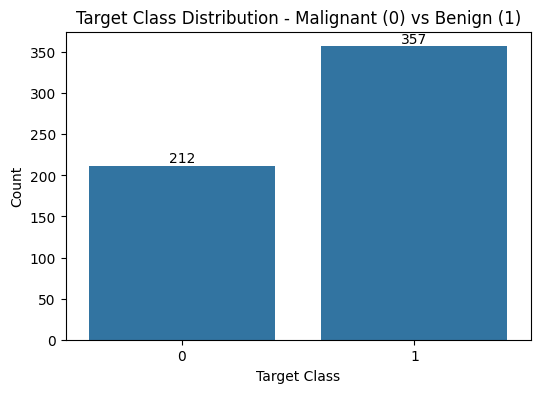

In [3]:
# Plot target class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y)

# Add labels on bars
for bar in ax.patches:
    ax.annotate(
        int(bar.get_height()),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Target Class Distribution - Malignant (0) vs Benign (1)")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()


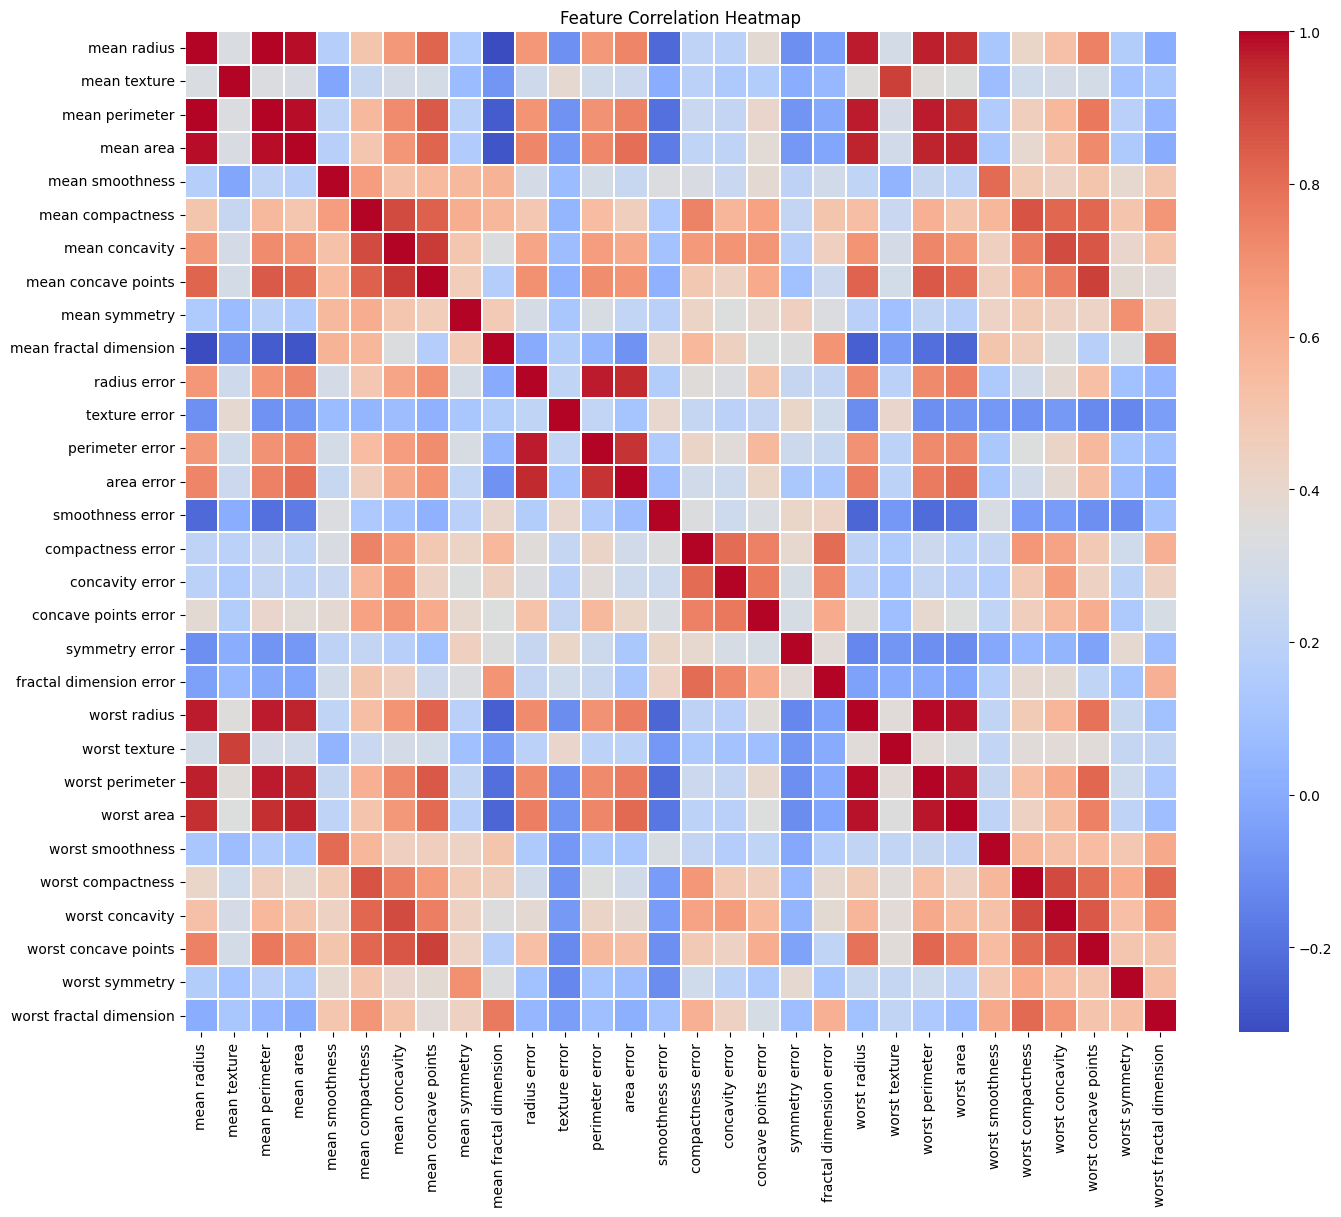

Top highly correlated feature pairs:
mean radius      mean perimeter     0.997855
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst perimeter  worst area         0.977578
radius error     perimeter error    0.972794
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
mean perimeter   worst radius       0.969476
dtype: float64


In [4]:
# Calculate feature correlation
corr = X.corr()

# Plot the 30 x 30 correlation heatmap
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Show some highly correlated feature pairs
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().sort_values(ascending=False)

print("Top highly correlated feature pairs:")
print(corr_pairs.head(10))


In [5]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check class proportions
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Training class proportions:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing class proportions:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [6]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_sc = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_sc = scaler.transform(X_test)

# Convert to DataFrames for easy checking
X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns, index=X_train.index)
X_test_sc = pd.DataFrame(X_test_sc, columns=X.columns, index=X_test.index)

# Check mean and standard deviation
print("Mean of first 5 scaled features:")
print(X_train_sc.mean().head())

print("\nStandard deviation of first 5 scaled features:")
print(X_train_sc.std().head())


Mean of first 5 scaled features:
mean radius       -2.928061e-16
mean texture       6.246530e-16
mean perimeter    -1.629954e-16
mean area         -1.717796e-16
mean smoothness    6.246530e-17
dtype: float64

Standard deviation of first 5 scaled features:
mean radius        1.001101
mean texture       1.001101
mean perimeter     1.001101
mean area          1.001101
mean smoothness    1.001101
dtype: float64


# Single-Layer Perceptron (SLP)


In [7]:
# Build the Single-Layer Perceptron
model_slp = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="sigmoid", input_shape=(30,))
])

# Display model summary
model_slp.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the SLP
model_slp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [9]:
# Train the SLP
history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2225 - loss: 1.6343 - val_accuracy: 0.2826 - val_loss: 1.3203
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2396 - loss: 1.4991 - val_accuracy: 0.2826 - val_loss: 1.2096
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2665 - loss: 1.3752 - val_accuracy: 0.3043 - val_loss: 1.1056
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3056 - loss: 1.2593 - val_accuracy: 0.3043 - val_loss: 1.0096
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3472 - loss: 1.1472 - val_accuracy: 0.3478 - val_loss: 0.9243
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3936 - loss: 1.0507 - val_accuracy: 0.3478 - val_loss: 0.8458
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4474 - loss: 0.9617 - val_accuracy: 0.4130 - val_loss: 0.7761
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4866 - loss: 0.8808 - val_accuracy: 0.5000 - va

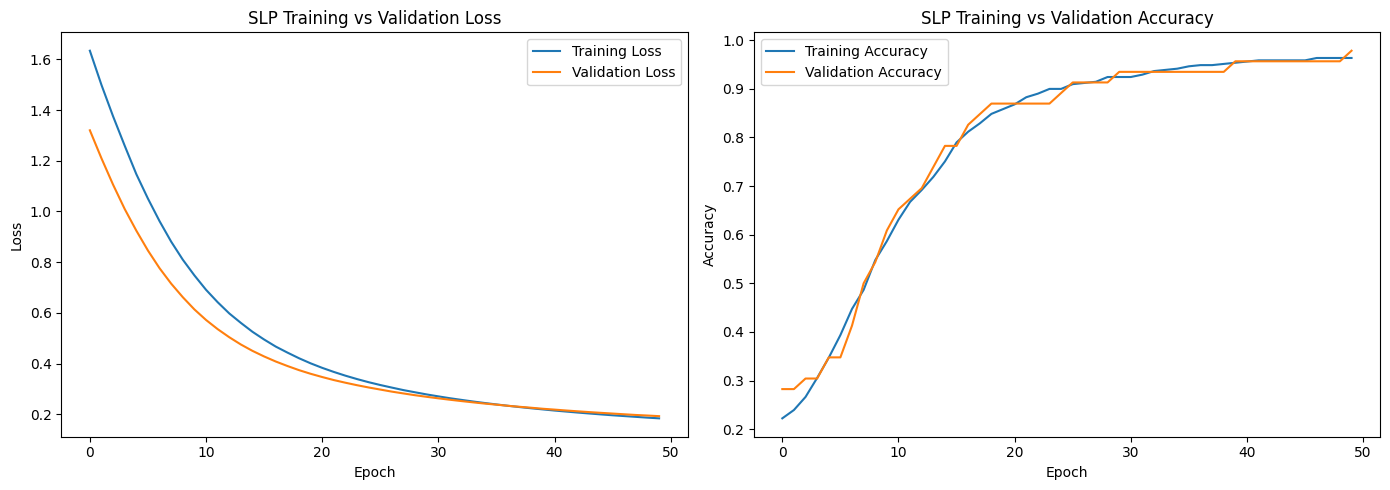

In [10]:
# Create a 1 x 2 figure
plt.figure(figsize=(14, 5))

# Training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history_slp.history["loss"], label="Training Loss")
plt.plot(history_slp.history["val_loss"], label="Validation Loss")
plt.title("SLP Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_slp.history["accuracy"], label="Training Accuracy")
plt.plot(history_slp.history["val_accuracy"], label="Validation Accuracy")
plt.title("SLP Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


SLP Test Accuracy: 0.9473684430122375

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Confusion Matrix:
[[39  3]
 [ 3 69]]


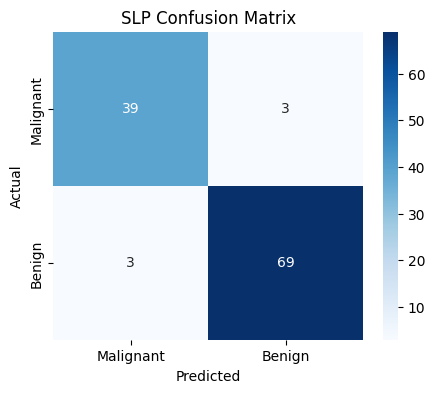

In [11]:
# Evaluate the SLP
slp_loss, slp_acc = model_slp.evaluate(X_test_sc, y_test, verbose=0)

# Predict probabilities
slp_prob = model_slp.predict(X_test_sc, verbose=0)

# Convert probabilities into classes
slp_pred = (slp_prob >= 0.5).astype(int).ravel()

# Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

print("SLP Test Accuracy:", slp_acc)

print("\nClassification Report:")
print(classification_report(y_test, slp_pred, target_names=["Malignant", "Benign"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, slp_pred))

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, slp_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.title("SLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Multi-Layer Perceptron (MLP)

In [12]:
# Build the MLP with ReLU hidden layers
model_mlp = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Display model summary
model_mlp.summary()

# Manual parameter calculation
params = (30 * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
print("Manual total parameter count:", params)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Manual total parameter count: 4097


In [13]:
# Compile the MLP
model_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the MLP
history_mlp = model_mlp.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9144 - loss: 0.4679 - val_accuracy: 0.8478 - val_loss: 0.3772
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9511 - loss: 0.2574 - val_accuracy: 0.9130 - val_loss: 0.2506
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9633 - loss: 0.1617 - val_accuracy: 0.9565 - val_loss: 0.1860
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9682 - loss: 0.1171 - val_accuracy: 0.9783 - val_loss: 0.1459
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9756 - loss: 0.0939 - val_accuracy: 0.9783 - val_loss: 0.1190
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9756 - loss: 0.0791 - val_accuracy: 0.9783 - val_loss: 0.0977
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9829 - loss: 0.0693 - val_accuracy: 0.9783 - val_loss: 0.0835
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9829 - loss: 0.0621 - val_accuracy: 0.

In [14]:
# ReLU model
model_relu = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_relu.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_relu = model_relu.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Tanh model
model_tanh = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="tanh", input_shape=(30,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_tanh.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_tanh = model_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Sigmoid hidden-layer model
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="sigmoid", input_shape=(30,)),
    tf.keras.layers.Dense(32, activation="sigmoid"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_sigmoid.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_sigmoid = model_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print("Activation function models trained.")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Activation function models trained.


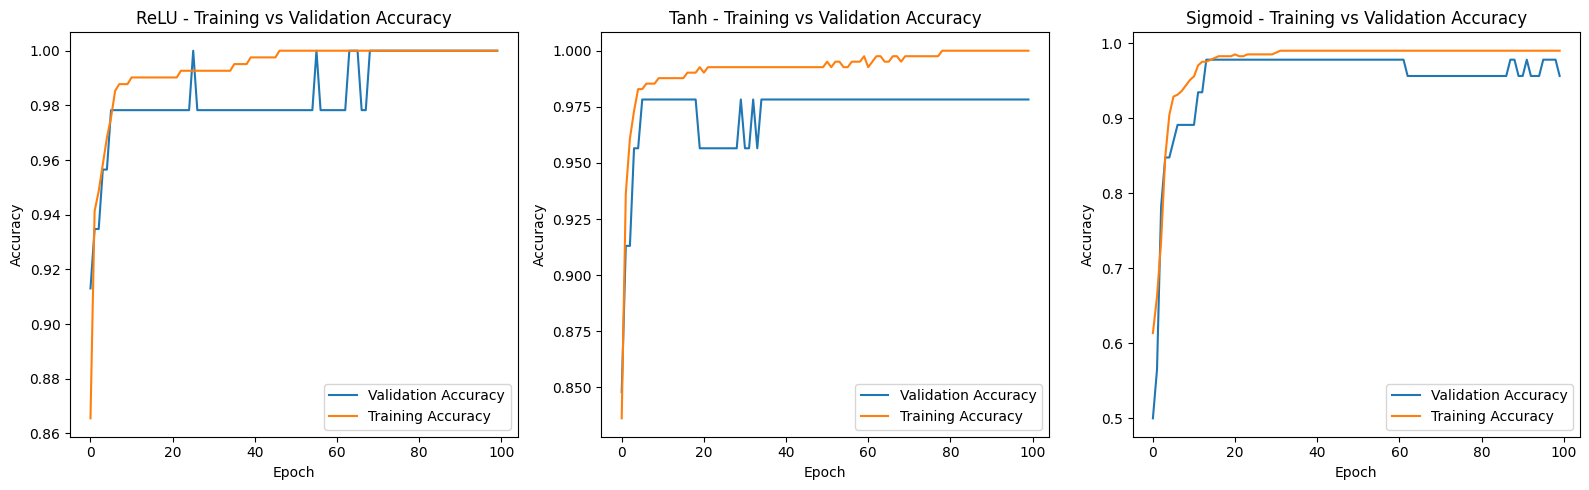

ReLU Test Accuracy: 0.9736841917037964
Tanh Test Accuracy: 0.9736841917037964
Sigmoid Test Accuracy: 0.9561403393745422


,Activation,Test Accuracy
0,ReLU,0.973684
1,Tanh,0.973684
2,Sigmoid,0.956140


In [15]:
# Plot validation accuracy for all three activation functions
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(history_relu.history["val_accuracy"], label="Validation Accuracy")
plt.plot(history_relu.history["accuracy"], label="Training Accuracy")
plt.title("ReLU - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_tanh.history["val_accuracy"], label="Validation Accuracy")
plt.plot(history_tanh.history["accuracy"], label="Training Accuracy")
plt.title("Tanh - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_sigmoid.history["val_accuracy"], label="Validation Accuracy")
plt.plot(history_sigmoid.history["accuracy"], label="Training Accuracy")
plt.title("Sigmoid - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate all three models
relu_loss, relu_acc = model_relu.evaluate(X_test_sc, y_test, verbose=0)
tanh_loss, tanh_acc = model_tanh.evaluate(X_test_sc, y_test, verbose=0)
sigmoid_loss, sigmoid_acc = model_sigmoid.evaluate(X_test_sc, y_test, verbose=0)

print("ReLU Test Accuracy:", relu_acc)
print("Tanh Test Accuracy:", tanh_acc)
print("Sigmoid Test Accuracy:", sigmoid_acc)

# Store activation results
activation_results = pd.DataFrame({
    "Activation": ["ReLU", "Tanh", "Sigmoid"],
    "Test Accuracy": [relu_acc, tanh_acc, sigmoid_acc]
})

display(activation_results)


# Evaluate Best MLP

In [16]:
# Find the best activation using test accuracy
best_activation = activation_results.loc[
    activation_results["Test Accuracy"].idxmax(),
    "Activation"
]

best_mlp_accuracy = activation_results["Test Accuracy"].max()

print("Best activation:", best_activation)
print("Best MLP test accuracy:", best_mlp_accuracy)

# Use the corresponding model
best_mlp_model = model_relu
best_mlp_model_name = "MLP - ReLU"

best_mlp_model.evaluate(X_test_sc, y_test, verbose=0)


Best activation: ReLU
Best MLP test accuracy: 0.9736841917037964


[0.13961263000965118, 0.9736841917037964]

#  Early Stopping


In [17]:
# Build a fresh larger MLP
model_es = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_es.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

# Create EarlyStopping callback
es = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Train with EarlyStopping
history_es = model_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)


Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8264 - loss: 0.4838 - val_accuracy: 0.9130 - val_loss: 0.3106
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9511 - loss: 0.1971 - val_accuracy: 0.9130 - val_loss: 0.2062
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1180 - val_accuracy: 0.9565 - val_loss: 0.1478
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.0876 - val_accuracy: 0.9565 - val_loss: 0.1059
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0710 - val_accuracy: 0.9565 - val_loss: 0.0817
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0610 - val_accuracy: 0.9565 - val_loss: 0.0724
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.0539 - val_accuracy: 0.9783 - val_loss: 0.0668
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9878 - loss: 0.0492 - val_accuracy: 0.9783 -

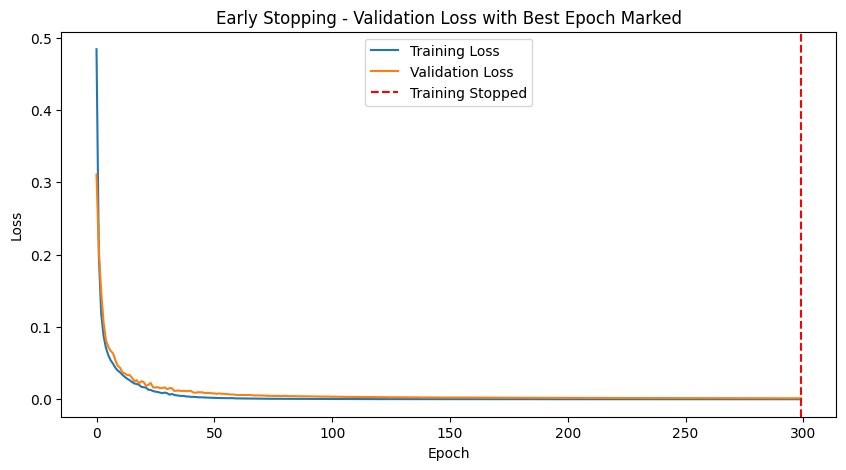

Training stopped after 300 epochs.
Best validation-loss epoch: 300


In [19]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_es.history["loss"], label="Training Loss")
plt.plot(history_es.history["val_loss"], label="Validation Loss")

# Mark the epoch where training stopped
stop_epoch = len(history_es.history["loss"])
best_epoch = np.argmin(history_es.history["val_loss"]) + 1

plt.axvline(
    stop_epoch - 1,
    linestyle="--",
    color="red",
    label="Training Stopped"
)

plt.title("Early Stopping - Validation Loss with Best Epoch Marked")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Training stopped after", stop_epoch, "epochs.")
print("Best validation-loss epoch:", best_epoch)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


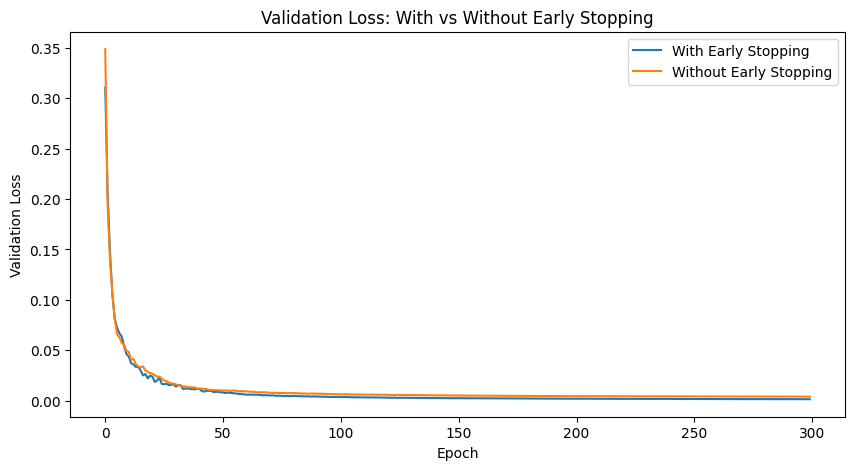

Early Stopping Test Accuracy: 0.9649122953414917
Without Early Stopping Test Accuracy: 0.9561403393745422


In [20]:
# Train the same architecture for all 300 epochs without EarlyStopping
model_no_es = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_no_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_no_es = model_no_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Compare validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_es.history["val_loss"], label="With Early Stopping")
plt.plot(history_no_es.history["val_loss"], label="Without Early Stopping")
plt.title("Validation Loss: With vs Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

# Evaluate both models
es_loss, es_acc = model_es.evaluate(X_test_sc, y_test, verbose=0)
no_es_loss, no_es_acc = model_no_es.evaluate(X_test_sc, y_test, verbose=0)

print("Early Stopping Test Accuracy:", es_acc)
print("Without Early Stopping Test Accuracy:", no_es_acc)


# Dropout Layers


In [21]:
# Build MLP with Dropout
model_drop = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Display model summary
model_drop.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# EarlyStopping for dropout model
es_drop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Compile
model_drop.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train
history_drop = model_drop.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_drop],
    verbose=1
)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7531 - loss: 0.5246 - val_accuracy: 0.9130 - val_loss: 0.3075
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9413 - loss: 0.2353 - val_accuracy: 0.9348 - val_loss: 0.1941
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9487 - loss: 0.1474 - val_accuracy: 0.9348 - val_loss: 0.1552
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.1079 - val_accuracy: 0.9565 - val_loss: 0.1269
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.0956 - val_accuracy: 0.9565 - val_loss: 0.1070
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.0909 - val_accuracy: 0.9565 - val_loss: 0.0918
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.0720 - val_accuracy: 0.9565 - val_loss: 0.0863
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0624 - val_accuracy: 0.9565 - 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


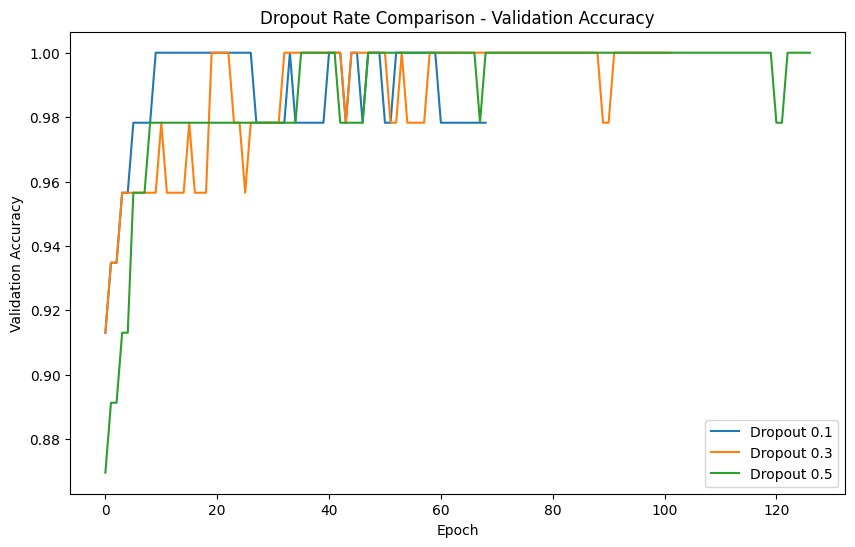

,Dropout Rate,Test Accuracy
0,0.1,0.964912
1,0.3,0.956140
2,0.5,0.956140


Best dropout rate: 0.1


In [23]:
# Dropout 0.1 model
model_drop_01 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_drop_01.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es_01 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_drop_01 = model_drop_01.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_01],
    verbose=0
)

# Dropout 0.5 model
model_drop_05 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_drop_05.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es_05 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_drop_05 = model_drop_05.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_05],
    verbose=0
)

# Plot validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_drop_01.history["val_accuracy"], label="Dropout 0.1")
plt.plot(history_drop.history["val_accuracy"], label="Dropout 0.3")
plt.plot(history_drop_05.history["val_accuracy"], label="Dropout 0.5")

plt.title("Dropout Rate Comparison - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# Evaluate all three dropout models
drop_01_acc = model_drop_01.evaluate(X_test_sc, y_test, verbose=0)[1]
drop_03_acc = model_drop.evaluate(X_test_sc, y_test, verbose=0)[1]
drop_05_acc = model_drop_05.evaluate(X_test_sc, y_test, verbose=0)[1]

dropout_results = pd.DataFrame({
    "Dropout Rate": [0.1, 0.3, 0.5],
    "Test Accuracy": [drop_01_acc, drop_03_acc, drop_05_acc]
})

display(dropout_results)

# Select best dropout model
best_dropout_index = dropout_results["Test Accuracy"].idxmax()
best_dropout_rate = dropout_results.loc[best_dropout_index, "Dropout Rate"]

print("Best dropout rate:", best_dropout_rate)


Dropout 0.3 Test Accuracy: 0.9561403393745422


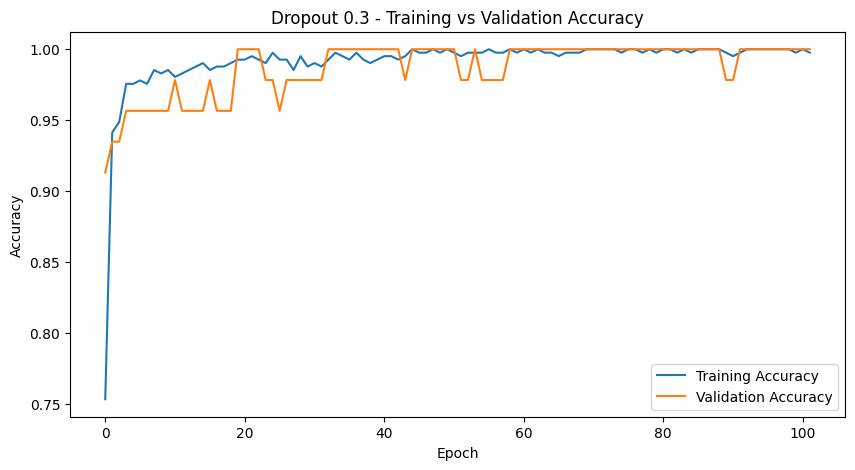

In [24]:
# Evaluate the 0.3 dropout model
drop_loss, drop_acc = model_drop.evaluate(X_test_sc, y_test, verbose=0)

print("Dropout 0.3 Test Accuracy:", drop_acc)

# Plot training vs validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_drop.history["accuracy"], label="Training Accuracy")
plt.plot(history_drop.history["val_accuracy"], label="Validation Accuracy")
plt.title("Dropout 0.3 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Regularization

In [25]:
# Import regularizers
from tensorflow.keras import regularizers

# Build L2 model
model_l2 = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile L2 model
model_l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
es_l2 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history_l2 = model_l2.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l2],
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8337 - loss: 0.5872 - val_accuracy: 0.9130 - val_loss: 0.4440
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9584 - loss: 0.3134 - val_accuracy: 0.9348 - val_loss: 0.3245
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9658 - loss: 0.2412 - val_accuracy: 0.9348 - val_loss: 0.2688
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.2103 - val_accuracy: 0.9565 - val_loss: 0.2314
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.1942 - val_accuracy: 0.9565 - val_loss: 0.2116
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.1824 - val_accuracy: 0.9565 - val_loss: 0.2025
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.1732 - val_accuracy: 0.9783 - val_loss: 0.1874
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9902 - loss: 0.1656 - val_accuracy: 0.9783 - val_loss: 

In [26]:
# Build L1 model
model_l1 = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l1(0.001)
    ),
    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001)
    ),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile L1 model
model_l1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
es_l1 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history_l1 = model_l1.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1],
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8802 - loss: 1.5232 - val_accuracy: 0.9348 - val_loss: 1.3537
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9535 - loss: 1.2314 - val_accuracy: 0.9348 - val_loss: 1.2083
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 1.1138 - val_accuracy: 0.9565 - val_loss: 1.1120
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 1.0359 - val_accuracy: 0.9565 - val_loss: 1.0229
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.9653 - val_accuracy: 0.9783 - val_loss: 0.9494
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.9006 - val_accuracy: 0.9783 - val_loss: 0.8841
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.8389 - val_accuracy: 0.9783 - val_loss: 0.8227
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.7791 - val_accuracy: 0.9783 - val_loss: 0.

In [27]:
# Build L1-L2 model
model_l12 = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)
    ),
    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)
    ),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile L1-L2 model
model_l12.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
es_l12 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history_l12 = model_l12.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l12],
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7922 - loss: 0.6801 - val_accuracy: 0.8913 - val_loss: 0.5433
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9511 - loss: 0.4182 - val_accuracy: 0.9130 - val_loss: 0.4414
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9682 - loss: 0.3473 - val_accuracy: 0.9565 - val_loss: 0.3851
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.3137 - val_accuracy: 0.9565 - val_loss: 0.3437
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.2959 - val_accuracy: 0.9565 - val_loss: 0.3146
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.2781 - val_accuracy: 0.9565 - val_loss: 0.3042
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.2653 - val_accuracy: 0.9565 - val_loss: 0.2962
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9902 - loss: 0.2536 - val_accuracy: 0.9565 - val_loss: 0

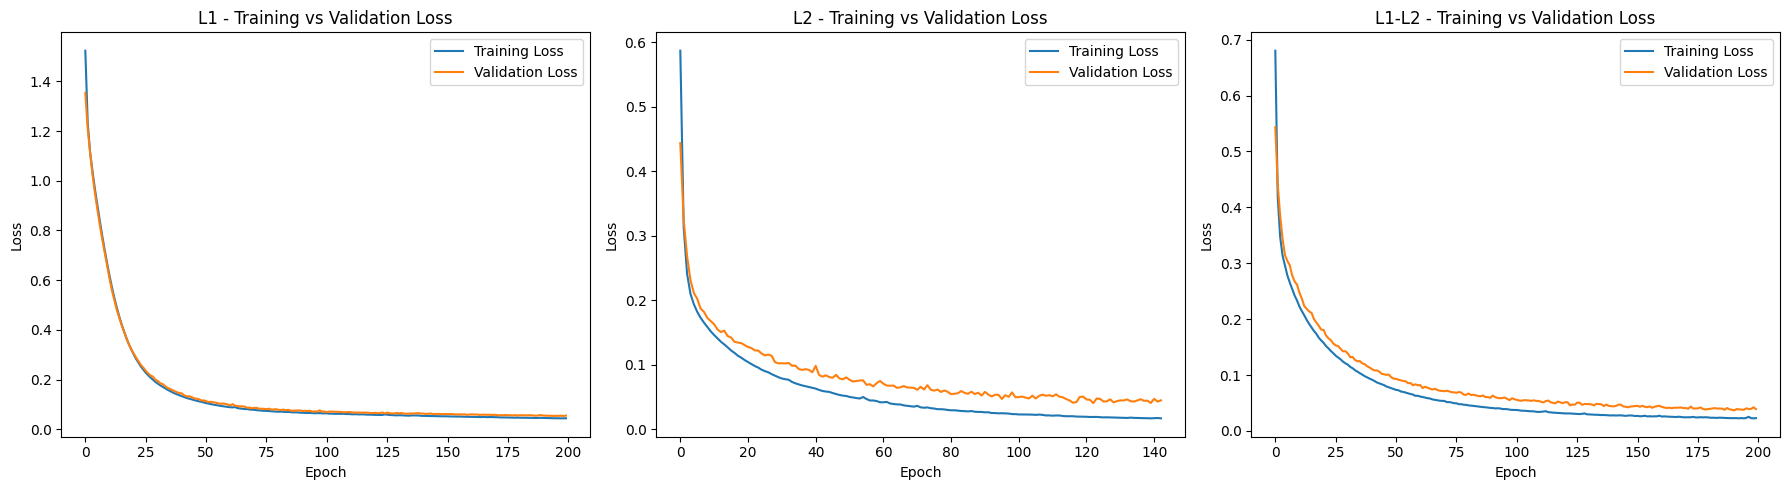

In [28]:
# Plot training vs validation loss for all regularized models
plt.figure(figsize=(18, 5))

# L1
plt.subplot(1, 3, 1)
plt.plot(history_l1.history["loss"], label="Training Loss")
plt.plot(history_l1.history["val_loss"], label="Validation Loss")
plt.title("L1 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# L2
plt.subplot(1, 3, 2)
plt.plot(history_l2.history["loss"], label="Training Loss")
plt.plot(history_l2.history["val_loss"], label="Validation Loss")
plt.title("L2 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# L1-L2
plt.subplot(1, 3, 3)
plt.plot(history_l12.history["loss"], label="Training Loss")
plt.plot(history_l12.history["val_loss"], label="Validation Loss")
plt.title("L1-L2 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


,Model,Test Accuracy
0,L1,0.95614
1,L2,0.95614
2,L1-L2,0.95614


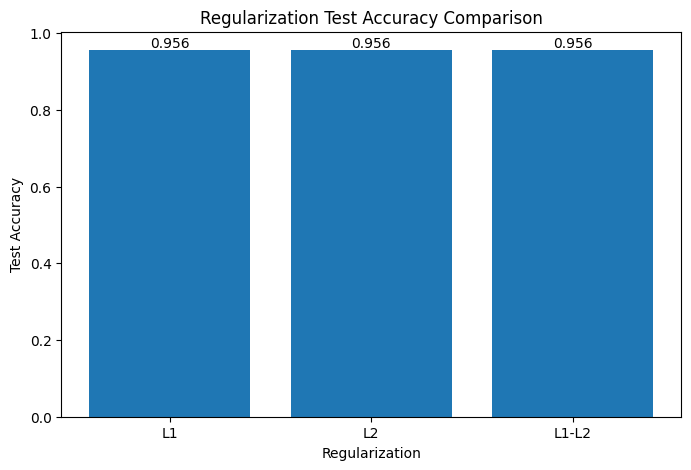

In [29]:
# Evaluate L1, L2 and L1-L2
l1_acc = model_l1.evaluate(X_test_sc, y_test, verbose=0)[1]
l2_acc = model_l2.evaluate(X_test_sc, y_test, verbose=0)[1]
l12_acc = model_l12.evaluate(X_test_sc, y_test, verbose=0)[1]

regularization_results = pd.DataFrame({
    "Model": ["L1", "L2", "L1-L2"],
    "Test Accuracy": [l1_acc, l2_acc, l12_acc]
})

display(regularization_results)

# Plot comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(
    regularization_results["Model"],
    regularization_results["Test Accuracy"]
)

plt.title("Regularization Test Accuracy Comparison")
plt.xlabel("Regularization")
plt.ylabel("Test Accuracy")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.show()


# Final Comparison, Business Insights & Notebook Quality


In [30]:
# Build final combined model
model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile final model
model_final.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping for final model
es_final = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train final model
history_final = model_final.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_final],
    verbose=1
)

# Evaluate final model
final_loss, final_acc = model_final.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Final Model Test Accuracy:", final_acc)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7751 - loss: 0.6069 - val_accuracy: 0.8913 - val_loss: 0.4282
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9389 - loss: 0.3518 - val_accuracy: 0.9348 - val_loss: 0.3351
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9535 - loss: 0.2789 - val_accuracy: 0.9783 - val_loss: 0.2874
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 0.2425 - val_accuracy: 0.9783 - val_loss: 0.2559
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.2241 - val_accuracy: 0.9783 - val_loss: 0.2329
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.2069 - val_accuracy: 0.9783 - val_loss: 0.2122
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - loss: 0.1969 - val_accuracy: 0.9783 - val_loss: 0.2006
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.1867 - val_accuracy: 0.9783 -

In [31]:
# Evaluate models for the final table
slp_accuracy = model_slp.evaluate(X_test_sc, y_test, verbose=0)[1]
relu_accuracy = model_relu.evaluate(X_test_sc, y_test, verbose=0)[1]
es_accuracy = model_es.evaluate(X_test_sc, y_test, verbose=0)[1]
dropout_accuracy = model_drop.evaluate(X_test_sc, y_test, verbose=0)[1]

# Build full results table
results = pd.DataFrame({
    "Model": [
        "SLP",
        "MLP - ReLU",
        "MLP + Early Stopping",
        "MLP + Dropout",
        "MLP + L2",
        "MLP + L1",
        "MLP + L1-L2",
        "Final Combined"
    ],
    "Architecture": [
        "30 -> 1",
        "30 -> 64 -> 32 -> 1",
        "30 -> 128 -> 64 -> 1",
        "30 -> 128 -> 64 -> 1",
        "30 -> 128 -> 64 -> 1",
        "30 -> 128 -> 64 -> 1",
        "30 -> 128 -> 64 -> 1",
        "30 -> 128 -> 64 -> 1"
    ],
    "Regularization": [
        "None",
        "None",
        "None",
        "None",
        "L2",
        "L1",
        "L1-L2",
        "L2"
    ],
    "Dropout Rate": [
        0.0,
        0.0,
        0.0,
        0.3,
        0.0,
        0.0,
        0.0,
        0.3
    ],
    "Early Stopping": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],
    "Test Accuracy": [
        slp_accuracy,
        relu_accuracy,
        es_accuracy,
        dropout_accuracy,
        l2_acc,
        l1_acc,
        l12_acc,
        final_acc
    ]
})

# Display the table
display(
    results.style.highlight_max(
        subset=["Test Accuracy"],
        color="#cccccc"
    )
)


,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy
0,SLP,30 -> 1,None,0.000000,No,0.947368
1,MLP - ReLU,30 -> 64 -> 32 -> 1,None,0.000000,No,0.973684
2,MLP + Early Stopping,30 -> 128 -> 64 -> 1,None,0.000000,Yes,0.964912
3,MLP + Dropout,30 -> 128 -> 64 -> 1,None,0.300000,Yes,0.956140
4,MLP + L2,30 -> 128 -> 64 -> 1,L2,0.000000,Yes,0.956140
5,MLP + L1,30 -> 128 -> 64 -> 1,L1,0.000000,Yes,0.956140
6,MLP + L1-L2,30 -> 128 -> 64 -> 1,L1-L2,0.000000,Yes,0.956140
7,Final Combined,30 -> 128 -> 64 -> 1,L2,0.300000,Yes,0.956140


## Clinical Insight Report


Final Model Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



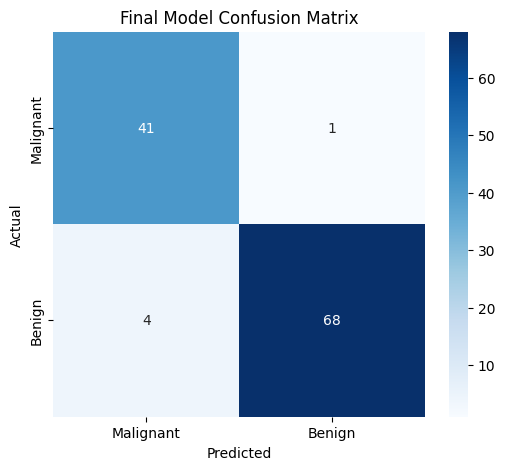

Malignant Recall: 0.9761904761904762
Malignant Precision: 0.9111111111111111


In [32]:
# Final model classification report
final_prob = model_final.predict(X_test_sc, verbose=0)
final_pred = (final_prob >= 0.5).astype(int).ravel()

print("Final Model Classification Report:")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Malignant", "Benign"]
    )
)

# Final confusion matrix
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate malignant recall
from sklearn.metrics import recall_score, precision_score

malignant_recall = recall_score(
    y_test,
    final_pred,
    pos_label=0
)

malignant_precision = precision_score(
    y_test,
    final_pred,
    pos_label=0
)

print("Malignant Recall:", malignant_recall)
print("Malignant Precision:", malignant_precision)


# Conclusion

This project demonstrates the progression from a simple Single-Layer Perceptron to a regularized deep neural network. The SLP provides a useful baseline, while hidden layers allow non-linear feature interactions. ReLU, tanh and sigmoid are compared experimentally. Early stopping, dropout and L1/L2 regularization are then tested as methods for improving generalisation. Finally, the best ideas are combined into a final model and evaluated using both accuracy and the confusion matrix.

For a medical application, the final model should not be deployed based on accuracy alone. Malignant-case recall and the consequences of false-negative predictions are especially important.
